# AdapTrans showcase: Transformer on CRCNS AA1

This notebook trains a small **Transformer** on the **CRCNS AA1**
auditory dataset (zebra finch primary auditory and midbrain neurons,
Theunissen group; auto-downloaded via deepSTRF's CRCNS helper) twice
— once **without** any prefiltering, once **with** an **AdapTrans**
prefilter (Rancon et al. 2022) — to demonstrate the prefilter's
contribution. AdapTrans is a learnable cochlear-adaptation
front-end: it implements per-band sliding-window subtractive
adaptation that mimics divisive cortical adaptation observed in
auditory neurons, and is a drop-in `prefiltering=` argument on every
audio model in the deepSTRF zoo.

The configuration below mirrors **Rançon et al. 2025** (the deepSTRF
paper): Field L cells only, conspecific natural-sound stimuli only,
millisecond temporal resolution (`dt_ms=1`), a 41-step band-causal
attention window, and validation-`cc_norm` early stopping with
patience 50 (no fixed epoch budget).

What you'll see:

1. Auto-load AA1, restrict to the Field L cells and the conspecific
   stimuli (the bidirectional rule from `data_paradigm.md` §8 drops
   any cell with no conspecific data).
2. Per-band stim standardization — required because AA1 spectrograms
   span ~0–24 in raw amplitude and Transformer attention saturates
   on those values.
3. Train two Transformers with identical hyperparameters except for
   the `prefiltering=` argument.
4. Compare validation curves, predicted vs recorded responses on a
   held-out test stimulus, per-cell test `cc_norm` (AdapTrans vs
   plain), and peek at the learned AdapTrans gain envelopes.


## Setup — Google Colab

If you're running this notebook on Google Colab, run the cell below
**once** to install deepSTRF from source. On a local install
(``pip install -e .``) it's a no-op.

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q git+https://github.com/urancon/deepSTRF.git
    print("deepSTRF installed from GitHub.")
else:
    print("Local environment — assuming deepSTRF is already importable.")


Local environment — assuming deepSTRF is already importable.


## Imports

In [2]:
%matplotlib inline
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

from deepSTRF.datasets.audio.CRCNS_AA1_Dataset import CRCNS_AA1_Dataset
from deepSTRF.models.audio import Transformer
from deepSTRF.models.prefiltering import make_prefiltering
from deepSTRF.training import Fitter, set_random_seed
from deepSTRF.utils.data import neural_collate

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


## 1. Load CRCNS AA1 — Field L cells, conspecific stimuli

`CRCNS_AA1_Dataset` ships 100 cells (50 Field L + 50 MLd) responding
to 20 conspecific natural-sound stimuli plus 10 broadband "flatrip"
noise stimuli; ~34% of (stim, cell) pairs are NaN-padded (cells that
only saw a subset of stims). We pass `areas=('Field_L',)` at
construction to load only the Field L cells, then narrow to
conspecific stimuli with `select_stims_by_attr` — the bidirectional
rule from
[`data_paradigm.md`](../docs/_source/md/data_paradigm.md) §8 drops
the one Field L cell that has no conspecific data
(`pipu1018_2_B`).

In [3]:
ds = CRCNS_AA1_Dataset(dt_ms=1, areas=('Field_L',))
print(f"Field L only: N={ds.N_neurons} cells, S={len(ds.stims)} stims, "
      f"F={ds.F} bands, dt={ds.dt} ms")

ds.select_stims_by_attr("type", "conspecific")
S_sel = list(ds.S_sel)
N_sel = len(ds._selected())
print(f"After select_stims_by_attr('type', 'conspecific'): "
      f"{len(S_sel)} stims, {N_sel} visible cells")


Field L only: N=50 cells, S=30 stims, F=32 bands, dt=1 ms
After select_stims_by_attr('type', 'conspecific'): 20 stims, 49 visible cells


## 2. Per-band stim standardization

AA1 spectrograms are large-amplitude (raw values up to ~24). The
Transformer's attention softmax becomes unstable on those scales —
without standardization, the loss diverges to NaN within a few
gradient steps. We compute per-band mean and std from the train+val
subset (stims 0..16 in the conspecific selection) and apply them to
**all** stims, so the held-out test stims are transformed with the
same statistics — the workflow `standardize_stims` is built for.

In [4]:
trainval_subset = S_sel[:17]   # 14 train + 3 val
stats = ds.standardize_stims(stim_indices=trainval_subset, per_band=True)
print(f"per-band mean range: [{stats['mean'].min():.3f}, {stats['mean'].max():.3f}]")
print(f"per-band std range:  [{stats['std'].min():.3f}, {stats['std'].max():.3f}]")
print(f"After standardization, stim 0 range: "
      f"[{ds.stims[S_sel[0]].min():.2f}, {ds.stims[S_sel[0]].max():.2f}]")


per-band mean range: [0.004, 0.465]
per-band std range:  [0.001, 0.501]
After standardization, stim 0 range: [-2.99, 12.70]


## 3. Train / val / test split

14 train / 3 val / 3 test, all conspecific.

In [5]:
train_idx = S_sel[:14]
val_idx   = S_sel[14:17]
test_idx  = S_sel[17:20]

train_loader = DataLoader(Subset(ds, train_idx), batch_size=1, shuffle=True,
                          collate_fn=neural_collate)
val_loader   = DataLoader(Subset(ds, val_idx),   batch_size=1, shuffle=False,
                          collate_fn=neural_collate)
test_loader  = DataLoader(Subset(ds, test_idx),  batch_size=1, shuffle=False,
                          collate_fn=neural_collate)
print(f"train: {len(train_idx)} stims | val: {len(val_idx)} | test: {len(test_idx)}")


train: 14 stims | val: 3 | test: 3


## 4. Fit-and-evaluate helper

One function builds a `Transformer` with the requested `prefiltering`,
fits it with **early stopping on val cc_norm (patience 50, no fixed
epoch budget)** — matching the Rançon et al. 2025 schedule — and
returns history + test metrics + (when applicable) the trained
prefilter for inspection. Each model uses a **41-step band-causal
attention window**, the longest used in that paper. Per-epoch logs
are printed so you can watch training progress.

In [6]:
def fit_transformer(name, prefilt_factory, max_epochs=2000, patience=50, seed=0):
    set_random_seed(seed)
    pre = prefilt_factory() if prefilt_factory is not None else None
    model = Transformer(
        n_frequency_bands=ds.F,
        embedding_dim=48, n_heads=2, n_layers=1,
        out_neurons=N_sel,
        freq_patch_size=ds.F, time_patch_size=1,
        context_window=41,
        prefiltering=pre,
    )
    n_params = model.count_trainable_params()
    print(f"\n=== {name} — params: {n_params:,} ===", flush=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)
    fitter = Fitter(
        model, train_loader, val_loader,
        optimizer=optimizer, device=device,
        max_epochs=max_epochs, patience=patience,
        monitor="val_cc_norm", mode="max",
        # default log_fn prints per-epoch lines to stdout
    )
    t0 = time.time()
    history = fitter.fit()
    elapsed = time.time() - t0
    test = fitter.evaluate(test_loader)
    print(f"=== {name} — stopped after {len(history)} epochs in {elapsed:.0f}s ===", flush=True)
    return {
        "name": name,
        "model": model,
        "history": history,
        "test_cc": test["cc"].cpu(),
        "test_cc_norm": test["cc_norm"].cpu(),
        "n_params": n_params,
        "elapsed": elapsed,
        "n_epochs": len(history),
    }


## 5. Two fits — without vs with AdapTrans

Same Transformer architecture (1-layer, 2-head, embedding 48,
41-step causal context), same data, same early-stopping schedule.
The only difference is the `prefiltering=` argument. Each fit runs
until val cc_norm has not improved for 50 consecutive epochs —
typically a few hundred epochs on a single GPU. Per-epoch lines
appear below.

In [7]:
print("Fitting two Transformers on AA1 Field L conspecific ...")
result_plain     = fit_transformer("Transformer (no prefilter)", None)
result_adaptrans = fit_transformer("Transformer + AdapTrans",
                                   lambda: make_prefiltering("adaptrans", ds.F, dt=ds.dt))


Fitting two Transformers on AA1 Field L conspecific ...

=== Transformer (no prefilter) — params: 32,257 ===


epoch    0 | train_loss=0.2263 | train_cc=0.0141 | train_cc_norm=0.0180 | val_loss=0.1207 | val_cc=0.0337 | val_cc_norm=0.0451


epoch    1 | train_loss=0.0777 | train_cc=0.0550 | train_cc_norm=0.0723 | val_loss=0.0471 | val_cc=0.0559 | val_cc_norm=0.0723


epoch    2 | train_loss=0.0449 | train_cc=0.0711 | train_cc_norm=0.0900 | val_loss=0.0302 | val_cc=0.0735 | val_cc_norm=0.0938


epoch    3 | train_loss=0.0376 | train_cc=0.0809 | train_cc_norm=0.1029 | val_loss=0.0256 | val_cc=0.0931 | val_cc_norm=0.1195


...

epoch  384 | train_loss=0.0092 | train_cc=0.6422 | train_cc_norm=0.8491 | val_loss=0.0147 | val_cc=0.4851 | val_cc_norm=0.6446


epoch  385 | train_loss=0.0092 | train_cc=0.6418 | train_cc_norm=0.8482 | val_loss=0.0149 | val_cc=0.4835 | val_cc_norm=0.6427


epoch  386 | train_loss=0.0092 | train_cc=0.6426 | train_cc_norm=0.8494 | val_loss=0.0149 | val_cc=0.4864 | val_cc_norm=0.6464


epoch  387 | train_loss=0.0091 | train_cc=0.6434 | train_cc_norm=0.8505 | val_loss=0.0148 | val_cc=0.4849 | val_cc_norm=0.6443


=== Transformer + AdapTrans — stopped after 388 epochs in 1917s ===


## 6. Training curves

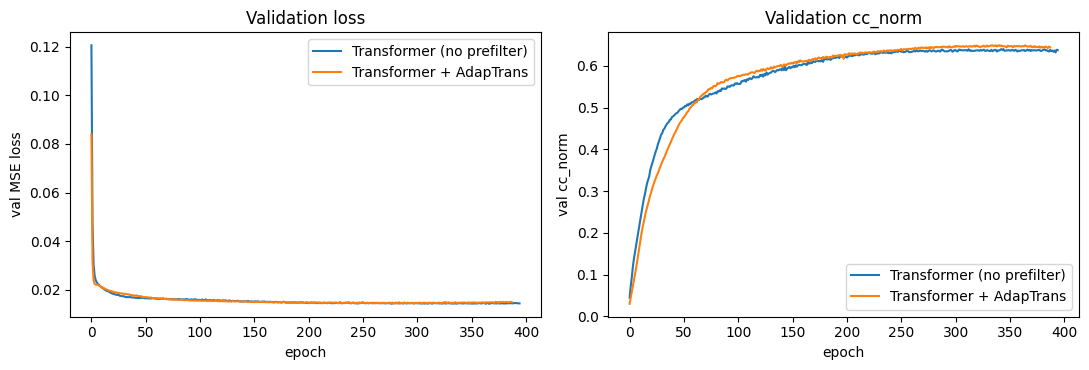

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
for r, c in [(result_plain, "tab:blue"), (result_adaptrans, "tab:orange")]:
    ep = [h["epoch"] for h in r["history"]]
    vL = [h["val_loss"] for h in r["history"]]
    vC = [torch.nanmean(h["val_cc_norm"]).item() for h in r["history"]]
    axs[0].plot(ep, vL, label=r["name"], color=c, lw=1.5)
    axs[1].plot(ep, vC, label=r["name"], color=c, lw=1.5)
axs[0].set_xlabel("epoch"); axs[0].set_ylabel("val MSE loss")
axs[0].legend(); axs[0].set_title("Validation loss")
axs[1].set_xlabel("epoch"); axs[1].set_ylabel("val cc_norm")
axs[1].legend(); axs[1].set_title("Validation cc_norm")
plt.tight_layout(); plt.show()


## 7. Test-set summary

In [9]:
print(f"{'configuration':<32s} {'params':>10s}  {'epochs':>7s}  {'fit (s)':>8s}  {'test cc (mean)':>16s}  {'test cc_norm (mean)':>22s}")
print("-" * 105)
for r in (result_plain, result_adaptrans):
    print(f"{r['name']:<32s} {r['n_params']:>10,}  {r['n_epochs']:>7d}  {r['elapsed']:>8.1f}  "
          f"{torch.nanmean(r['test_cc']):>+16.3f}  {torch.nanmean(r['test_cc_norm']):>+22.3f}")


configuration                        params   epochs   fit (s)    test cc (mean)     test cc_norm (mean)
---------------------------------------------------------------------------------------------------------
Transformer (no prefilter)           32,257      395    2021.8            +0.506                  +0.654
Transformer + AdapTrans              33,889      388    1916.7            +0.509                  +0.660


## 8. Predicted vs recorded responses on a test stimulus

A canonical sanity-check figure for population auditory recordings:
the input spectrogram on top, the trial-averaged ground-truth
firing rates as a population raster (one row per neuron, sorted by
test cc_norm — best-fit cells at top), and the AdapTrans model's
prediction below it on the same color scale and the same neuron
ordering.

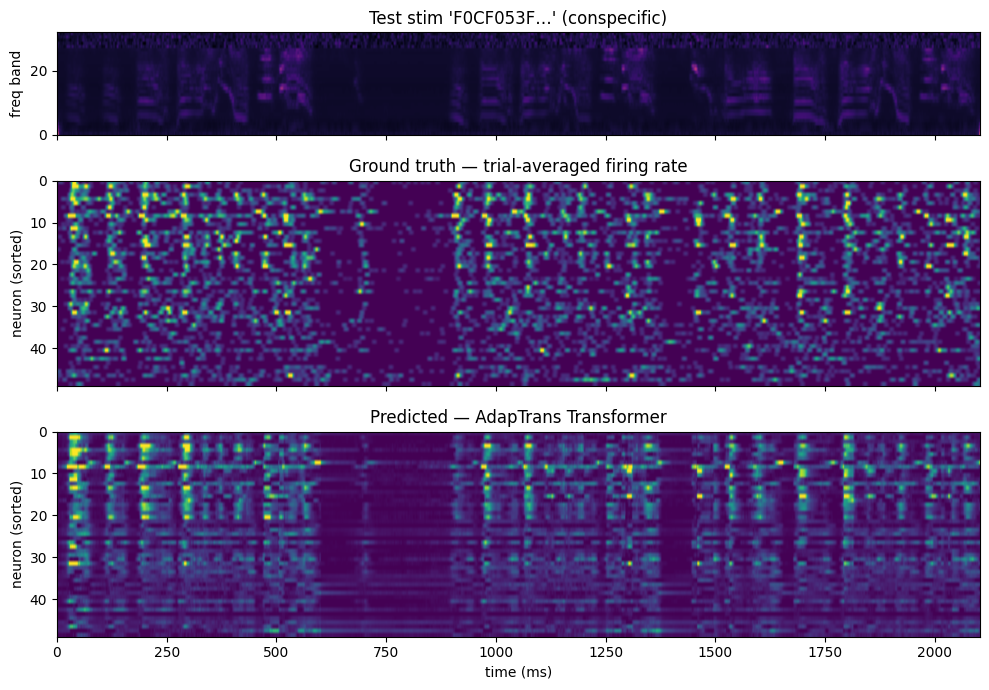

In [10]:
# Pick one held-out test stim
stim_iter_idx = test_idx[0]   # iter-space index, fetched via ds[i]
stim_t, resps_t, _, meta_t = ds[stim_iter_idx]
spec = stim_t.squeeze(0).cpu().numpy()                     # drop channel → (F, T)
T = spec.shape[1]

# Ground truth: trial-mean per cell (R varies between cells), then stack → (N, T)
gt = torch.stack([r.nanmean(dim=0) for r in resps_t], dim=0).cpu().numpy()

# Prediction from the AdapTrans model
result_adaptrans["model"].eval().to(device)
with torch.no_grad():
    x = stim_t.unsqueeze(0).to(device)                     # (1, 1, F, T)
    pred = result_adaptrans["model"](x)                    # (1, N, 1, T)
pr = pred.squeeze(0).squeeze(1).cpu().numpy()              # (N, T)

# Sort neurons by AdapTrans test cc_norm (best at top)
order = torch.argsort(result_adaptrans["test_cc_norm"], descending=True).numpy()
gt_s, pr_s = gt[order], pr[order]

# Shared color scale across gt / pred
vmax = float(np.nanpercentile(np.concatenate([gt_s, pr_s], axis=1), 99.5))

t = np.arange(T) * ds.dt   # ms

fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True,
                        gridspec_kw={"height_ratios": [1, 2, 2]})

axs[0].imshow(spec, aspect='auto', origin='lower',
              extent=[t[0], t[-1], 0, ds.F], cmap='magma')
axs[0].set_ylabel("freq band")
axs[0].set_title(f"Test stim '{meta_t['name'][:8]}…' ({meta_t['type']})")

axs[1].imshow(gt_s, aspect='auto', origin='upper',
              extent=[t[0], t[-1], gt_s.shape[0], 0],
              cmap='viridis', vmin=0, vmax=vmax)
axs[1].set_ylabel("neuron (sorted)")
axs[1].set_title("Ground truth — trial-averaged firing rate")

axs[2].imshow(pr_s, aspect='auto', origin='upper',
              extent=[t[0], t[-1], pr_s.shape[0], 0],
              cmap='viridis', vmin=0, vmax=vmax)
axs[2].set_ylabel("neuron (sorted)")
axs[2].set_xlabel("time (ms)")
axs[2].set_title("Predicted — AdapTrans Transformer")

plt.tight_layout(); plt.show()


## 9. Per-cell test cc_norm — AdapTrans vs no prefilter

Each dot is one Field L cell. Points above the diagonal are cells
where AdapTrans helps; below, where it hurts. The diagonal makes the
per-cell improvement visually direct (a common figure in the
literature for ablations of this kind).

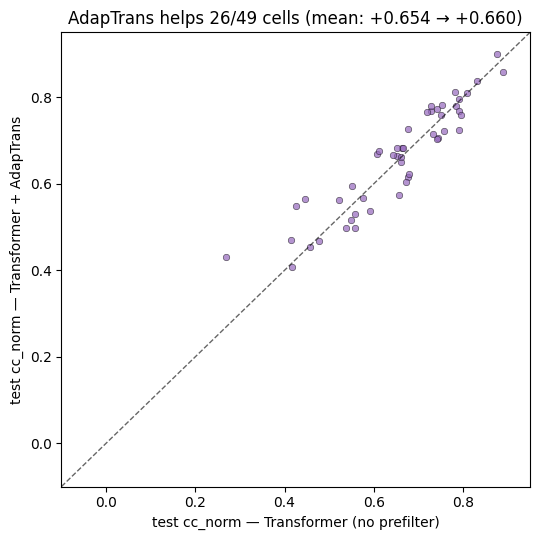

In [11]:
plain = result_plain["test_cc_norm"].numpy()
adapt = result_adaptrans["test_cc_norm"].numpy()
both_ok = ~(np.isnan(plain) | np.isnan(adapt))
plain, adapt = plain[both_ok], adapt[both_ok]

fig, ax = plt.subplots(figsize=(5.5, 5.5))
lo, hi = -0.1, 0.95
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.6)
ax.scatter(plain, adapt, s=22, alpha=0.7, color='tab:purple', edgecolor='black', linewidth=0.4)

n_above = int((adapt > plain).sum())
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("test cc_norm — Transformer (no prefilter)")
ax.set_ylabel("test cc_norm — Transformer + AdapTrans")
ax.set_title(f"AdapTrans helps {n_above}/{len(plain)} cells "
             f"(mean: {plain.mean():+.3f} → {adapt.mean():+.3f})")
plt.tight_layout(); plt.show()


## 10. Inspect the learned AdapTrans filters

AdapTrans's per-band time-constants are derived from the cochlear
frequency map at init. After training the model adjusts them
independently for the ON and OFF channels. The two panels below show
the learned per-band ``a`` (related to adaptation time-constant — the
larger ``a``, the slower the adaptation) and the ON/OFF kernel for a
representative band.

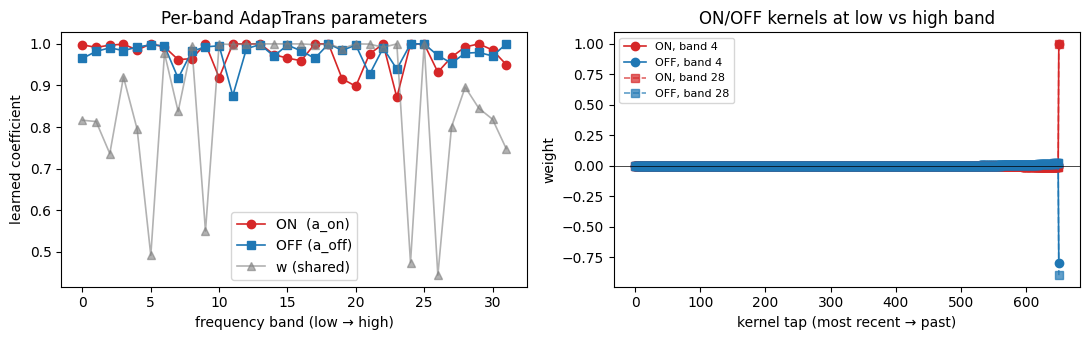

In [12]:
adaptrans = result_adaptrans["model"].prefiltering
a_on, a_off = adaptrans.get_a()
w = adaptrans.get_w()

fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))
F_bands = np.arange(adaptrans.F)
axs[0].plot(F_bands, a_on.numpy(),  marker='o', lw=1.2, label='ON  (a_on)',  color='tab:red')
axs[0].plot(F_bands, a_off.numpy(), marker='s', lw=1.2, label='OFF (a_off)', color='tab:blue')
axs[0].plot(F_bands, w.numpy(),     marker='^', lw=1.2, label='w (shared)',  color='tab:gray', alpha=0.6)
axs[0].set_xlabel("frequency band (low → high)")
axs[0].set_ylabel("learned coefficient")
axs[0].set_title("Per-band AdapTrans parameters")
axs[0].legend()

# Show the ON / OFF kernels for a low-frequency and a high-frequency band
with torch.no_grad():
    k_on, k_off = adaptrans.build_kernels()
band_lo, band_hi = 4, adaptrans.F - 4
axs[1].plot(k_on[band_lo, 0].cpu().numpy(),  marker='o', lw=1.2, color='tab:red',
            label=f'ON, band {band_lo}')
axs[1].plot(k_off[band_lo, 0].cpu().numpy(), marker='o', lw=1.2, color='tab:blue',
            label=f'OFF, band {band_lo}')
axs[1].plot(k_on[band_hi, 0].cpu().numpy(),  marker='s', lw=1.2, color='tab:red',
            ls='--', alpha=0.7, label=f'ON, band {band_hi}')
axs[1].plot(k_off[band_hi, 0].cpu().numpy(), marker='s', lw=1.2, color='tab:blue',
            ls='--', alpha=0.7, label=f'OFF, band {band_hi}')
axs[1].axhline(0, color='k', lw=0.5)
axs[1].set_xlabel("kernel tap (most recent → past)")
axs[1].set_ylabel("weight")
axs[1].set_title("ON/OFF kernels at low vs high band")
axs[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## What's next

- **Compare AdapTrans against ICAdaptation** (Willmore et al. 2016
  baseline) — same model, three prefiltering choices: `None`,
  `make_prefiltering('icadaptation', ...)` (paper-faithful, fixed
  time-constants), and `make_prefiltering('adaptrans', ...)`
  (learnable). The two cochlear-adaptation prefilters typically
  match each other and beat `None`; the difference between them is
  small but consistent.
- **Cross-dataset AdapTrans** — same prefilter, fit on NS1, AA1, and
  NAT4 jointly via `concat_neural_datasets`. AdapTrans's per-band
  time-constants generalise across datasets if the spectrogram
  resolution (`F`, `dt`) is shared.
